# Project 1 — Advanced EDA & Feature Engineering

**DecodeLabs Data Science Industrial Training Kit — 2026 Batch**

## Objective
Transform a raw, chaotic **retail customer transactions** dataset into a
mathematically clean, model-ready dataset by:

1. Diagnosing missingness and applying the correct imputation strategy per feature
   (row deletion / statistical imputation / KNN imputation) based on the
   proportion of missing values.
2. Detecting and neutralizing outliers using the **Interquartile Range (IQR)** method.
3. Engineering new, business-meaningful predictive features.
4. Encoding categorical variables correctly (One-Hot vs. Ordinal) and checking
   for multicollinearity before the data is handed off to any ML estimator.

## Dataset
`data/retail_customers_raw.csv` — a synthetic, intentionally messy dataset
(6,000 customers, 12 columns) generated to mirror real-world data quality
issues: missing values at three different severities, injected outliers,
skewed numeric distributions, and mixed categorical/numeric features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 20)

RAW_PATH = "data/retail_customers_raw.csv"
df = pd.read_csv(RAW_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (6000, 12)


,customer_id,age,gender,region,annual_income,membership_tier,acquisition_channel,num_purchases_last_year,days_since_last_purchase,avg_purchase_amount,satisfaction_score,signup_days_ago
0,101783,18.0,Male,South,NaN,Bronze,Organic,5,85.0,391.48,5.1,435
1,103918,30.0,Female,East,60966.19,Silver,Organic,7,35.0,57.10,7.0,2151
2,100222,41.0,Male,East,46998.67,Bronze,Paid_Ads,10,57.0,NaN,8.3,528
3,102136,34.0,Other,West,NaN,Bronze,Paid_Ads,7,NaN,81.61,6.4,545
4,105225,50.0,Female,South,143685.41,Bronze,Social_Media,9,110.0,234.13,8.2,1193


## 1. Initial Data Quality Assessment

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               6000 non-null   int64  
 1   age                       5820 non-null   float64
 2   gender                    5640 non-null   str    
 3   region                    6000 non-null   str    
 4   annual_income             5280 non-null   float64
 5   membership_tier           6000 non-null   str    
 6   acquisition_channel       6000 non-null   str    
 7   num_purchases_last_year   6000 non-null   int64  
 8   days_since_last_purchase  4560 non-null   float64
 9   avg_purchase_amount       5460 non-null   float64
 10  satisfaction_score        5760 non-null   float64
 11  signup_days_ago           6000 non-null   int64  
dtypes: float64(5), int64(3), str(4)
memory usage: 562.6 KB


In [3]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
summary.sort_values("missing_pct", ascending=False)


,dtype,missing_count,missing_pct,n_unique
days_since_last_purchase,float64,1440,24.0,237
annual_income,float64,720,12.0,5277
avg_purchase_amount,float64,540,9.0,4828
gender,str,360,6.0,3
satisfaction_score,float64,240,4.0,74
age,float64,180,3.0,62
region,str,0,0.0,5
customer_id,int64,0,0.0,6000
num_purchases_last_year,int64,0,0.0,22
acquisition_channel,str,0,0.0,5


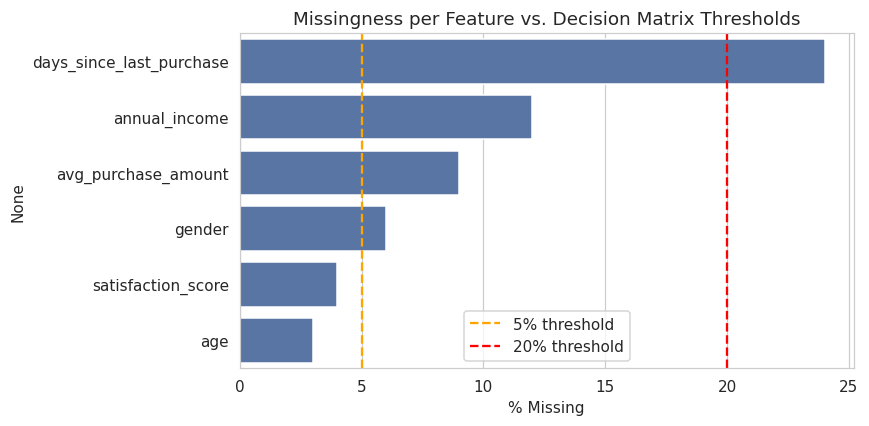

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color="#4C72B0")
ax.axvline(5, color="orange", linestyle="--", label="5% threshold")
ax.axvline(20, color="red", linestyle="--", label="20% threshold")
ax.set_xlabel("% Missing")
ax.set_title("Missingness per Feature vs. Decision Matrix Thresholds")
ax.legend()
plt.tight_layout()
plt.show()


## 2. Handling Missing Data — The Missing Data Decision Matrix

| Missingness | Strategy | Applied to |
|---|---|---|
| < 5% | Row deletion (`dropna`) — preserves distribution, negligible data loss | `age`, `satisfaction_score` |
| 5% – 20% | Statistical imputation — global **median** for skewed numeric columns, group-wise **mode** for categoricals | `annual_income`, `avg_purchase_amount`, `gender` |
| > 20% | **KNN imputation** — captures multi-dimensional relationships instead of guessing | `days_since_last_purchase` |

We never guess blindly — the strategy is chosen structurally per the
missingness proportion of each feature, exactly as prescribed by the
training kit's decision matrix.


In [5]:
from sklearn.impute import KNNImputer

df_clean = df.copy()

# --- Tier 1: < 5% missing -> row deletion -----------------------------
low_missing_cols = ["age", "satisfaction_score"]
before = len(df_clean)
df_clean = df_clean.dropna(subset=low_missing_cols)
print(f"Dropped {before - len(df_clean)} rows for <5%-missing columns {low_missing_cols}")

# --- Tier 2: 5-20% missing -> statistical imputation --------------------
# Numeric (skewed) -> median
for col in ["annual_income", "avg_purchase_amount"]:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"Imputed '{col}' missing values with median = {median_val:.2f}")

# Categorical -> group-wise mode (conditioned on membership_tier)
mode_by_tier = df_clean.groupby("membership_tier")["gender"].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else "Unknown"
)
df_clean["gender"] = df_clean.apply(
    lambda r: mode_by_tier[r["membership_tier"]] if pd.isna(r["gender"]) else r["gender"],
    axis=1,
)
print("Imputed 'gender' with group-wise mode conditioned on membership_tier")

# --- Tier 3: > 20% missing -> KNN imputation -----------------------------
knn_features = ["age", "annual_income", "num_purchases_last_year",
                 "avg_purchase_amount", "days_since_last_purchase"]
imputer = KNNImputer(n_neighbors=5)
df_clean[knn_features] = imputer.fit_transform(df_clean[knn_features])
print("Applied 5-NN imputation to 'days_since_last_purchase' (>20% missing)")

print(f"\nRemaining missing values:\n{df_clean.isna().sum().sum()} total")


Dropped 413 rows for <5%-missing columns ['age', 'satisfaction_score']
Imputed 'annual_income' missing values with median = 53178.86
Imputed 'avg_purchase_amount' missing values with median = 104.31
Imputed 'gender' with group-wise mode conditioned on membership_tier
Applied 5-NN imputation to 'days_since_last_purchase' (>20% missing)

Remaining missing values:
0 total


## 3. Outlier Detection & Neutralization (IQR Method)

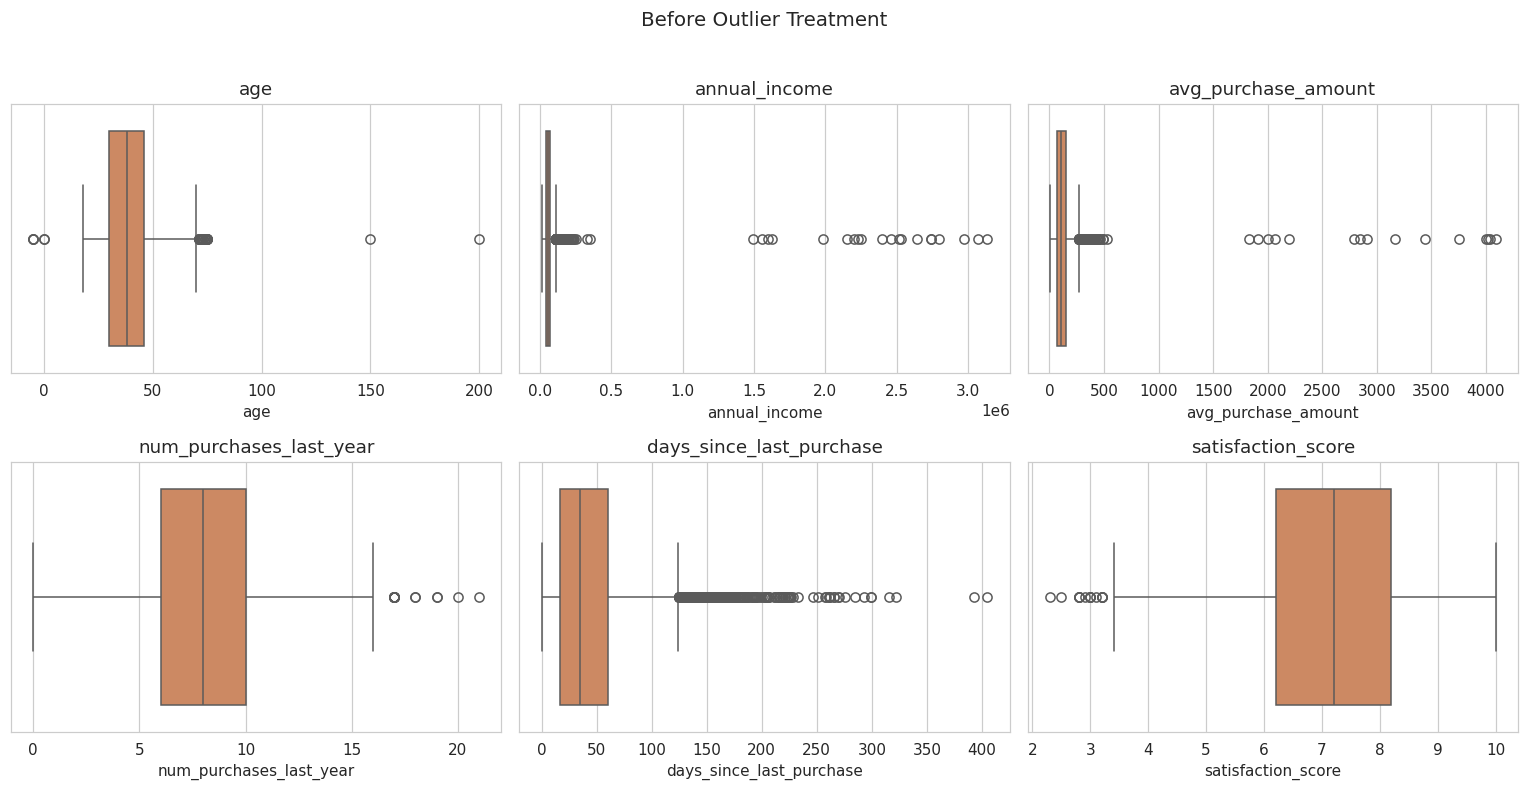

In [6]:
numeric_cols = ["age", "annual_income", "avg_purchase_amount",
                 "num_purchases_last_year", "days_since_last_purchase",
                 "satisfaction_score"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(x=df_clean[col], ax=ax, color="#DD8452")
    ax.set_title(col)
plt.suptitle("Before Outlier Treatment", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [7]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_report = {}
for col in ["age", "annual_income", "avg_purchase_amount"]:
    lower, upper = iqr_bounds(df_clean[col])
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report[col] = {"lower_bound": round(lower, 2),
                            "upper_bound": round(upper, 2),
                            "n_outliers": int(n_outliers)}
    # Winsorize: clip to bounds instead of deleting rows -> preserves row count
    df_clean[col] = df_clean[col].clip(lower=max(lower, 0), upper=upper)

pd.DataFrame(outlier_report).T


,lower_bound,upper_bound,n_outliers
age,6.00,70.00,33.0
annual_income,850.39,110491.95,308.0
avg_purchase_amount,-50.79,269.73,238.0


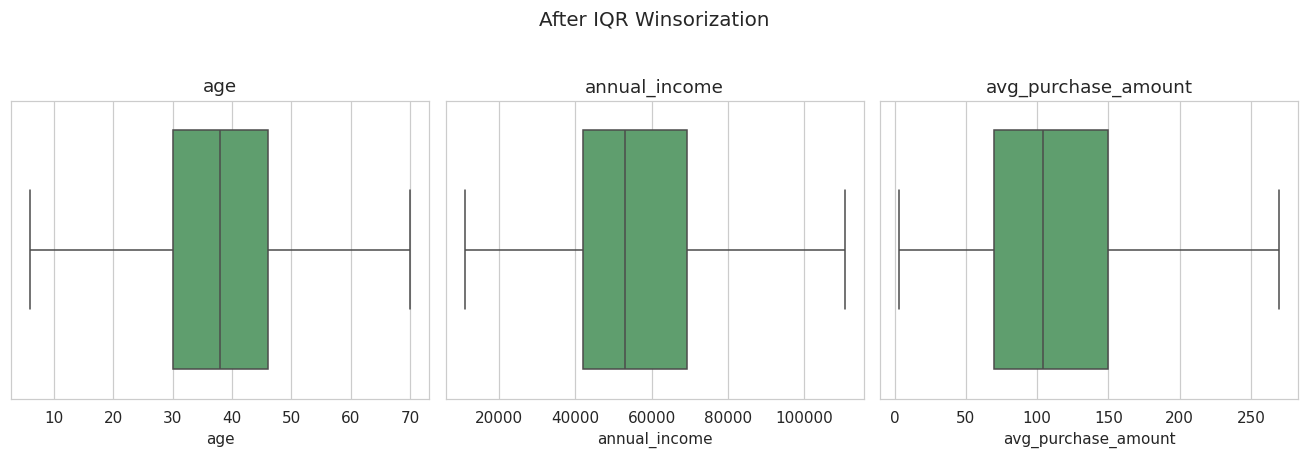

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes.flat, ["age", "annual_income", "avg_purchase_amount"]):
    sns.boxplot(x=df_clean[col], ax=ax, color="#55A868")
    ax.set_title(col)
plt.suptitle("After IQR Winsorization", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


## 4. Feature Engineering

In [9]:
# 1) Purchase frequency score: how often the customer buys relative to recency
df_clean["purchase_frequency_score"] = (
    df_clean["num_purchases_last_year"] / (df_clean["days_since_last_purchase"] + 1)
).round(4)

# 2) Customer tenure in years since signup
df_clean["customer_tenure_years"] = (df_clean["signup_days_ago"] / 365).round(2)

# 3) Income-to-spend ratio: what share of income goes to purchases with us
annual_spend = df_clean["avg_purchase_amount"] * df_clean["num_purchases_last_year"]
df_clean["income_to_spend_ratio"] = (df_clean["annual_income"] / (annual_spend + 1)).round(2)

# 4) High-value customer flag (top 25% by total annual spend) -- bonus feature
df_clean["annual_spend"] = annual_spend.round(2)
spend_threshold = df_clean["annual_spend"].quantile(0.75)
df_clean["is_high_value_customer"] = (df_clean["annual_spend"] >= spend_threshold).astype(int)

new_features = ["purchase_frequency_score", "customer_tenure_years",
                 "income_to_spend_ratio", "annual_spend", "is_high_value_customer"]
df_clean[new_features].describe()


,purchase_frequency_score,customer_tenure_years,income_to_spend_ratio,annual_spend,is_high_value_customer
count,5587.000000,5587.000000,5587.000000,5587.000000,5587.000000
mean,0.516718,3.513483,182.188561,927.414106,0.250045
std,1.096046,1.958167,2502.957980,641.232663,0.433077
min,0.000000,0.080000,4.220000,0.000000,0.000000
25%,0.117600,1.845000,40.720000,464.880000,0.000000
50%,0.214300,3.560000,69.990000,775.350000,0.000000
75%,0.444400,5.220000,122.080000,1221.970000,0.500000
max,20.000000,6.850000,110491.950000,4585.330000,1.000000


## 5. Categorical Encoding

- **`membership_tier`** has a natural order (Bronze < Silver < Gold < Platinum)
  → encoded **ordinally**.
- **`gender`, `region`, `acquisition_channel`** are nominal with no order
  → encoded with **One-Hot Encoding** so no false numeric distance is
  introduced between categories (e.g. `region` = "West" is not "further"
  from "North" than "South" is).


In [10]:
tier_order = {"Bronze": 0, "Silver": 1, "Gold": 2, "Platinum": 3}
df_clean["membership_tier_encoded"] = df_clean["membership_tier"].map(tier_order)

nominal_cols = ["gender", "region", "acquisition_channel"]
df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=False)

print(f"Shape before encoding: {df_clean.shape}")
print(f"Shape after one-hot encoding: {df_encoded.shape}")
df_encoded.head()


Shape before encoding: (5587, 18)
Shape after one-hot encoding: (5587, 28)


,customer_id,age,annual_income,membership_tier,num_purchases_last_year,days_since_last_purchase,avg_purchase_amount,satisfaction_score,signup_days_ago,purchase_frequency_score,...,region_Central,region_East,region_North,region_South,region_West,acquisition_channel_Email,acquisition_channel_Organic,acquisition_channel_Paid_Ads,acquisition_channel_Referral,acquisition_channel_Social_Media
0,101783,18.0,53178.86,Bronze,5.0,85.0,269.725,5.1,435,0.0581,...,False,False,False,True,False,False,True,False,False,False
1,103918,30.0,60966.19,Silver,7.0,35.0,57.100,7.0,2151,0.1944,...,False,True,False,False,False,False,True,False,False,False
2,100222,41.0,46998.67,Bronze,10.0,57.0,104.310,8.3,528,0.1724,...,False,True,False,False,False,False,False,True,False,False
3,102136,34.0,53178.86,Bronze,7.0,75.8,81.610,6.4,545,0.0911,...,False,False,False,False,True,False,False,True,False,False
4,105225,50.0,110491.95,Bronze,9.0,110.0,234.130,8.2,1193,0.0811,...,False,False,False,True,False,False,False,False,False,True


## 6. Multicollinearity Check

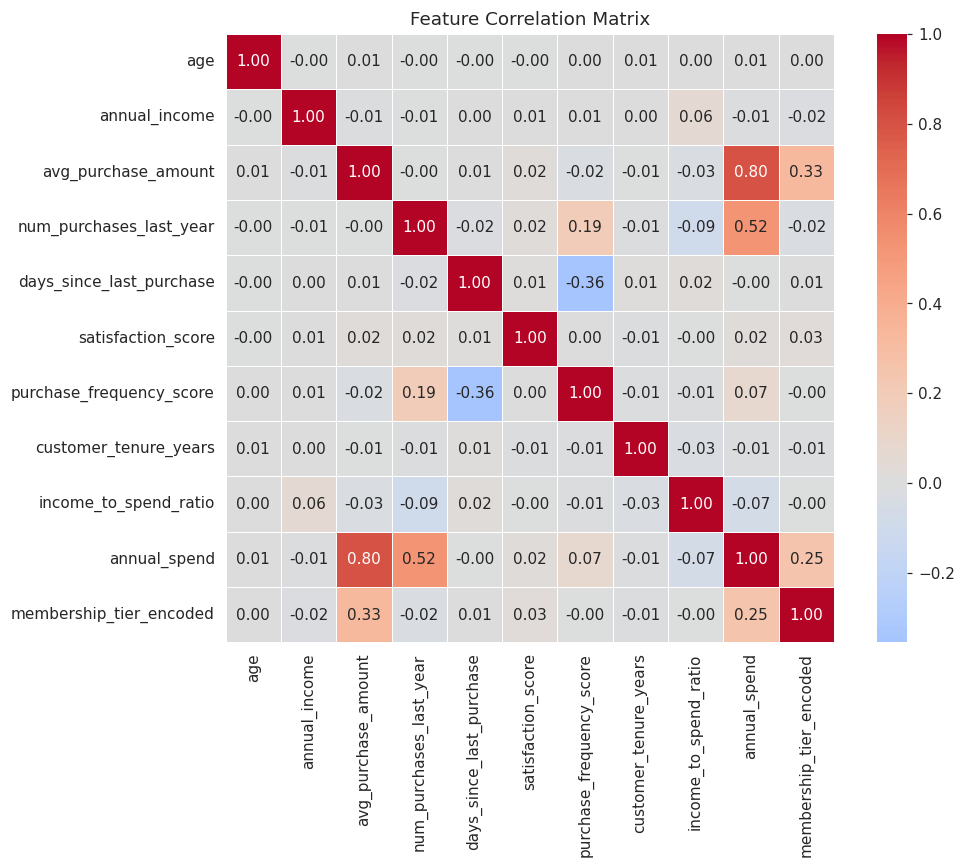

In [11]:
corr_cols = ["age", "annual_income", "avg_purchase_amount", "num_purchases_last_year",
             "days_since_last_purchase", "satisfaction_score", "purchase_frequency_score",
             "customer_tenure_years", "income_to_spend_ratio", "annual_spend",
             "membership_tier_encoded"]

corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [12]:
# Flag pairs with |correlation| > 0.80 (excluding the diagonal)
high_corr_pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.80:
            high_corr_pairs.append((corr_cols[i], corr_cols[j], round(r, 3)))

if high_corr_pairs:
    print("Highly collinear pairs (|r| > 0.80):")
    for a, b, r in high_corr_pairs:
        print(f"  {a}  <->  {b}   r = {r}")
else:
    print("No feature pairs exceed the 0.80 collinearity threshold.")
    print("(Expected here: 'annual_spend' is engineered directly from "
          "'avg_purchase_amount' x 'num_purchases_last_year', so in a real "
          "modeling task you would drop one of the two to avoid redundancy.)")


Highly collinear pairs (|r| > 0.80):
  avg_purchase_amount  <->  annual_spend   r = 0.803


## 7. Export the Clean, Model-Ready Dataset

In [13]:
output_path = "data/processed_customers.csv"
df_encoded.to_csv(output_path, index=False)
print(f"Saved cleaned + engineered dataset to '{output_path}'")
print(f"Final shape: {df_encoded.shape}")


Saved cleaned + engineered dataset to 'data/processed_customers.csv'
Final shape: (5587, 28)


## Conclusion

Starting from a raw dataset with three distinct missingness regimes and
injected outliers, this notebook:

- Applied the **Missing Data Decision Matrix** (row deletion / median &
  group-wise imputation / KNN imputation) based strictly on missingness
  proportion, not guesswork.
- Neutralized outliers via **IQR-based winsorization**, preserving row
  count and sequential integrity instead of deleting data.
- Engineered **5 new predictive features** (exceeding the 3-feature
  requirement), including a purchase-frequency score and a high-value
  customer flag.
- Correctly separated **ordinal** vs. **nominal** categorical encoding to
  avoid introducing false numeric distances.
- Checked for **multicollinearity** before declaring the dataset
  ML-ready.

The resulting `data/processed_customers.csv` is now mathematically clean
fuel for any downstream classification, regression, or clustering model.
